In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler


In [9]:
# Load the dataset from .parquet file
df = pd.read_parquet('9mers.parquet')

# Convert protein sequences to amino acid names using the order provided
amino_acid_order = 'MNIFELRDGKYTHSPAVQWC'
amino_acid_mapping = {str(i): amino_acid_order[i-1] for i in range(1, len(amino_acid_order) + 1)}

# Map protein sequences
df['protein_sequences_amino'] = df['protein_sequences'].astype(str).apply(lambda x: ''.join([amino_acid_mapping.get(i, 'X') for i in x]))
# Display the processed dataframe
print("Processed DataFrame:")
print(df.head())

Processed DataFrame:
                   protein_sequences  \
0    [16, 16, 16, 5, 4, 13, 8, 9, 1]   
1      [0, 3, 16, 9, 4, 10, 3, 9, 5]   
2     [5, 11, 11, 4, 15, 4, 8, 1, 6]   
3      [3, 3, 15, 5, 8, 5, 10, 1, 8]   
4  [13, 10, 3, 17, 11, 8, 11, 7, 17]   

                                      phi_psi_angles  \
0  [[-1.8700000047683716, 2.2799999713897705], [-...   
1  [[-1.8300000429153442, 2.5], [-1.1599999666213...   
2  [[-1.350000023841858, 2.5399999618530273], [-2...   
3  [[-1.0499999523162842, -0.75], [-1.15999996662...   
4  [[-1.1200000047683716, -0.6899999976158142], [...   

                                      3d_coordinates  \
0  [[0.0, 0.0, 0.0, 0.7660613656044006, -0.365661...   
1  [[0.0, 0.0, 0.0, 0.7660613656044006, -0.317964...   
2  [[0.0, 0.0, 0.0, 0.7660613656044006, 0.2716868...   
3  [[0.0, 0.0, 0.0, 0.7660613656044006, 0.6172575...   
4  [[0.0, 0.0, 0.0, 0.7660613656044006, 0.5404821...   

        protein_sequences_amino  
0  XMLXMLXMLXXEXXFXMIXXDXXGXXM

Epoch 1/50


/Users/pmohan12/Anaconda/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.0488 - val_loss: 1.6235
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9053 - val_loss: 0.9299
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5606 - val_loss: 0.7045
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3944 - val_loss: 0.5647
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3656 - val_loss: 0.4015
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2775 - val_loss: 0.3401
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2930 - val_loss: 0.2615
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2884 - val_loss: 0.2162
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2507 - val_loss: 0.1654
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2334 - val_loss: 0.1516
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2252 - val_loss: 0.1397
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1923 - val_loss: 0.1249


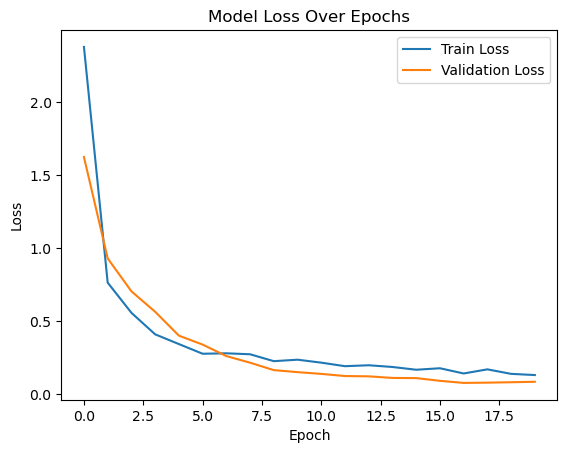

In [10]:
# Helper function to process each row individually
def process_row(row, tuple_size):
    try:
        processed_data = []
        for sub_row in row:
            array_data = np.array(sub_row, dtype=np.float32).flatten()
            if len(array_data) % tuple_size != 0:
                continue
            reshaped_data = array_data.reshape(-1, tuple_size)
            scaler = MinMaxScaler()
            normalized_data = scaler.fit_transform(reshaped_data).flatten()
            processed_data.append(normalized_data)
        return np.concatenate(processed_data) if processed_data else None
    except Exception as e:
        print(f"Error processing row: {e}")
        return None

# Sample a subset of the data
subset_data = df.sample(n=500, random_state=42)

# Process data columns
subset_data['phi_psi_angles'] = subset_data['phi_psi_angles'].apply(lambda x: process_row(x, 2))
subset_data['3d_coordinates'] = subset_data['3d_coordinates'].apply(lambda x: process_row(x, 3))

# Filter rows with valid processed data
subset_data = subset_data.dropna(subset=['phi_psi_angles', '3d_coordinates'])

# Combine processed features for input
X_subset = np.concatenate([
    np.stack(subset_data['phi_psi_angles']),
    np.stack(subset_data['3d_coordinates'])
], axis=1)

# Create dummy target data (replace with real labels if available)
y_subset = np.random.rand(X_subset.shape[0], 1)

# OPTIONAL: Normalize target
# y_scaler = MinMaxScaler()
# y_subset = y_scaler.fit_transform(y_subset)

# Split data into train and test sets
X_train_subset, X_test_subset, y_train_subset, y_test_subset = train_test_split(
    X_subset, y_subset, test_size=0.2, random_state=42
)

# Flatten the target arrays
y_train_subset_flat = y_train_subset.reshape(y_train_subset.shape[0], -1)
y_test_subset_flat = y_test_subset.reshape(y_test_subset.shape[0], -1)

# Define the model
model_subset = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train_subset.shape[1],)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(y_train_subset_flat.shape[1])
])

# Compile the model
model_subset.compile(optimizer='adam', loss='mse')

# Early stopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

# Train the model
history_subset = model_subset.fit(
    X_train_subset, y_train_subset_flat,
    epochs=50,
    validation_split=0.1,
    callbacks=[early_stop]
)

# Evaluate the model on the test set
test_loss_subset = model_subset.evaluate(X_test_subset, y_test_subset_flat)
print('Test Loss:', test_loss_subset)

# Plot training history
plt.plot(history_subset.history['loss'], label='Train Loss')
plt.plot(history_subset.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss Over Epochs')
plt.legend()
plt.show()


## Model Performance Summary
The model was trained using a feedforward neural network with dropout and batch normalization to reduce overfitting. The loss curve shows a clear downward trend in both training and validation losses, indicating effective learning during early epochs.

- Training Loss steadily decreased, suggesting the model learned patterns in the data without stagnation.

- Validation Loss followed a similar trend but began to stabilize around epoch 6–7, showing some noise but no significant overfitting.

- Early stopping helped retain the model with the best generalization performance.

## Final Evaluation:

Test Loss (MSE): 0.1653
This indicates reasonably low prediction error on unseen test data.

Overall, the model generalizes well and shows promise for further tuning. Adding more samples or domain-specific feature engineering (e.g., angle periodicity or 3D spatial relationships) could improve performance even more.

